In [2]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from idlpy import *
from scipy import stats
import statsmodels.api as sm

seasons = ['summer','autumn','winter','spring']

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

A new version is available: IDL 8.9
https://www.l3harrisgeospatial.com/Product-Downloads/
 
Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024


In [5]:
for s in ['winter','spring','summer','autumn']:
    
    print(s)
    
    nat_season_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_nat_'+s+'_pr_gaussian_ensMean.nc')
    ts = nat_season_mean.mean(['lat','lon']).values
    result = stats.linregress([i for i in range(len(ts))], ts)
    lin_regression = [i*result.slope + result.intercept for i in range(len(ts))]

    linreg_da = xr.DataArray(
        data=np.array(lin_regression),
        dims=["time"],
        coords=dict(
            time=nat_season_mean.time.values
        )
    )

    # subtract nat trend from each all- and nat- ensemble member
    for ens_mem in range(1,51):

        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

        for scen in ['all','nat']:
            ens_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_'+scen+'_'+s+'_pr_gaussian_ens'+number+'.nc')
    
            diff = ens_mem - linreg_da
        
            diff.to_netcdf('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/detrend_nat/ECHAM5_'+scen+'_'+s+'_pr_gaussian_ens'+number+'.nc')
            
            # subtract nat trend from ensemble mean
            ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_'+scen+'_'+s+'_pr_gaussian_ensMean.nc')
            diff = ens_mean - linreg_da
            diff.to_netcdf('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/detrend_nat/ECHAM5_'+scen+'_'+s+'_pr_gaussian_ensMean.nc')


winter
spring
summer
autumn


In [6]:
for s in ['winter','spring','summer','autumn']:
    
    print(s)
    
    nat_season_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/runoff/seasonal/ECHAM5_nat_'+s+'_mrro_gaussian_ensMean.nc')
    ts = nat_season_mean.mean(['lat','lon']).values
    result = stats.linregress([i for i in range(len(ts))], ts)
    lin_regression = [i*result.slope + result.intercept for i in range(len(ts))]

    linreg_da = xr.DataArray(
        data=np.array(lin_regression),
        dims=["time"],
        coords=dict(
            time=nat_season_mean.time.values
        )
    )

    # subtract nat trend from each all- and nat- ensemble member
    for ens_mem in range(1,51):

        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

        for scen in ['all','nat']:
            ens_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/runoff/seasonal/ECHAM5_'+scen+'_'+s+'_mrro_gaussian_ens'+number+'.nc')
    
            diff = ens_mem - linreg_da
        
            diff.to_netcdf('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/runoff/seasonal/detrend_nat/ECHAM5_'+scen+'_'+s+'_mrro_gaussian_ens'+number+'.nc')
            
            # subtract nat trend from ensemble mean
            ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/runoff/seasonal/ECHAM5_'+scen+'_'+s+'_mrro_gaussian_ensMean.nc')
            diff = ens_mean - linreg_da
            diff.to_netcdf('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/runoff/seasonal/detrend_nat/ECHAM5_'+scen+'_'+s+'_mrro_gaussian_ensMean.nc')


winter
spring
summer
autumn


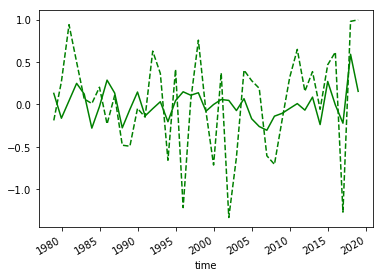

In [13]:
nat_reg = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_nat_summer_pr_gaussian_ens15.nc')
nat_detrended = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/detrend_nat/ECHAM5_nat_summer_pr_gaussian_ens15.nc')

all_reg = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_all_summer_pr_gaussian_ens15.nc')
all_detrended = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/detrend_nat/ECHAM5_all_summer_pr_gaussian_ens15.nc')

nat_detrended = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/detrend_nat/ECHAM5_nat_summer_pr_gaussian_ensMean.nc')

nat_reg.mean(['lat','lon']).plot(c='green',linestyle='--')
nat_detrended.mean(['lat','lon']).plot(c='green')


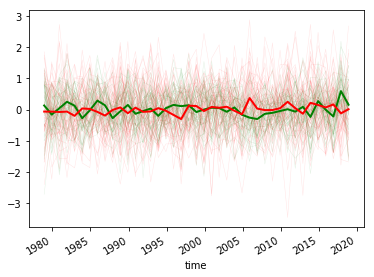

In [8]:
colors = {'ant':'red','nat':'green'}

nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/detrend_nat/ECHAM5_nat_summer_pr_gaussian_ensMean.nc')
all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_all_summer_pr_gaussian_ensMean.nc')

ant_mean = all_mean - nat_mean

for ens_mem in range(1,51):

    number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

    nat_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/detrend_nat/ECHAM5_nat_summer_pr_gaussian_ens'+number+'.nc')
    all_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_all_summer_pr_gaussian_ens'+number+'.nc')

    ant_mem = all_mem - nat_mem
    
    nat_mem.mean(['lat','lon']).plot(c=colors['nat'],linewidth=0.5,alpha=0.1)
    ant_mem.mean(['lat','lon']).plot(c=colors['ant'],linewidth=0.5,alpha=0.1)

nat_mean.mean(['lat','lon']).plot(c=colors['nat'],linewidth=2)
ant_mean.mean(['lat','lon']).plot(c=colors['ant'],linewidth=2)

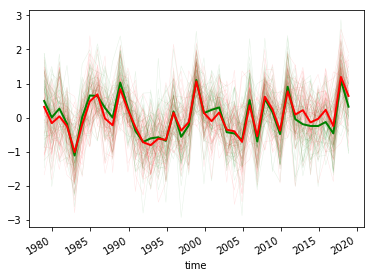

In [40]:
colors = {'ant':'red','nat':'green'}

nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/detrend_nat/ECHAM5_nat_summer_tasmax_gaussian_ensMean.nc')
all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/detrend_nat/ECHAM5_all_summer_tasmax_gaussian_ensMean.nc')

ant_mean = all_mean - nat_mean

for ens_mem in range(1,51):

    number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

    nat_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/detrend_nat/ECHAM5_nat_summer_tasmax_gaussian_ens'+number+'.nc')
    all_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/detrend_nat/ECHAM5_all_summer_tasmax_gaussian_ens'+number+'.nc')

    ant_mem = all_mem - nat_mem
    
    nat_mem.mean(['lat','lon']).plot(c=colors['nat'],linewidth=0.5,alpha=0.1)
    all_mem.mean(['lat','lon']).plot(c=colors['ant'],linewidth=0.5,alpha=0.1)

nat_mean.mean(['lat','lon']).plot(c=colors['nat'],linewidth=2)
all_mean.mean(['lat','lon']).plot(c=colors['ant'],linewidth=2)

In [19]:
da

<xarray.DataArray (time: 41)>
array([-2.51247812e-01, -2.38685422e-01, -2.26123031e-01, -2.13560640e-01,
       -2.00998250e-01, -1.88435859e-01, -1.75873468e-01, -1.63311077e-01,
       -1.50748687e-01, -1.38186296e-01, -1.25623905e-01, -1.13061514e-01,
       -1.00499124e-01, -8.79367330e-02, -7.53743423e-02, -6.28119515e-02,
       -5.02495608e-02, -3.76871701e-02, -2.51247794e-02, -1.25623886e-02,
        2.07632733e-09,  1.25623928e-02,  2.51247835e-02,  3.76871742e-02,
        5.02495650e-02,  6.28119557e-02,  7.53743464e-02,  8.79367371e-02,
        1.00499128e-01,  1.13061519e-01,  1.25623909e-01,  1.38186300e-01,
        1.50748691e-01,  1.63311081e-01,  1.75873472e-01,  1.88435863e-01,
        2.00998254e-01,  2.13560644e-01,  2.26123035e-01,  2.38685426e-01,
        2.51247817e-01])
Coordinates:
  * time     (time) datetime64[ns] 1978-12-01 1979-12-01 ... 2018-12-01

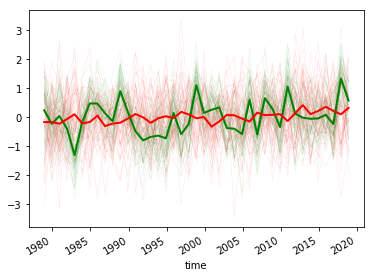

In [17]:
colors = {'ant':'red','nat':'green'}

nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_nat_summer_tasmax_gaussian_ensMean.nc')
all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_all_summer_tasmax_gaussian_ensMean.nc')

ant_mean = all_mean - nat_mean

for ens_mem in range(1,51):

    number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

    nat_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_nat_summer_tasmax_gaussian_ens'+number+'.nc')
    all_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_all_summer_tasmax_gaussian_ens'+number+'.nc')

    ant_mem = all_mem - nat_mem
    
    nat_mem.mean(['lat','lon']).plot(c=colors['nat'],linewidth=0.5,alpha=0.1)
    ant_mem.mean(['lat','lon']).plot(c=colors['ant'],linewidth=0.5,alpha=0.1)

nat_mean.mean(['lat','lon']).plot(c=colors['nat'],linewidth=2)
ant_mean.mean(['lat','lon']).plot(c=colors['ant'],linewidth=2)

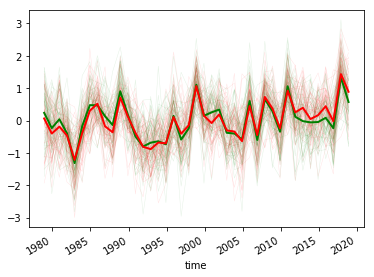

In [3]:
colors = {'ant':'red','nat':'green'}

nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_nat_summer_tasmax_gaussian_ensMean.nc')
all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_all_summer_tasmax_gaussian_ensMean.nc')

ant_mean = all_mean - nat_mean

for ens_mem in range(1,51):

    number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

    nat_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_nat_summer_tasmax_gaussian_ens'+number+'.nc')
    all_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_all_summer_tasmax_gaussian_ens'+number+'.nc')

    ant_mem = all_mem - nat_mem
    
    nat_mem.mean(['lat','lon']).plot(c=colors['nat'],linewidth=0.5,alpha=0.1)
    all_mem.mean(['lat','lon']).plot(c=colors['ant'],linewidth=0.5,alpha=0.1)

nat_mean.mean(['lat','lon']).plot(c=colors['nat'],linewidth=2)
all_mean.mean(['lat','lon']).plot(c=colors['ant'],linewidth=2)

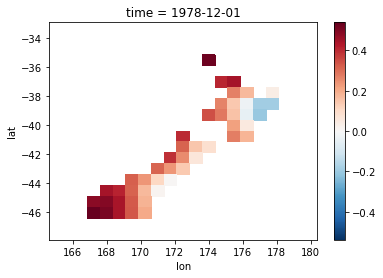

In [4]:
nat_mean.isel(time=0).plot()

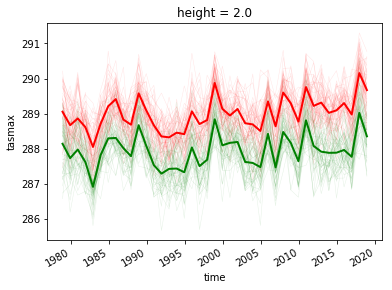

In [19]:
colors = {'ant':'red','nat':'green'}

nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/raw/tasmax/seasonal/ECHAM5_nat_summer_tasmax_ensMean.nc')
all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/raw/tasmax/seasonal/ECHAM5_all_summer_tasmax_ensMean.nc')

ant_mean = all_mean - nat_mean

for ens_mem in range(1,51):

    number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

    nat_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/raw/tasmax/seasonal/ECHAM5_nat_summer_tasmax_ens'+number+'.nc')
    all_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/raw/tasmax/seasonal/ECHAM5_all_summer_tasmax_ens'+number+'.nc')

    ant_mem = all_mem - nat_mem
    
    nat_mem.mean(['lat','lon']).plot(c=colors['nat'],linewidth=0.5,alpha=0.1)
    all_mem.mean(['lat','lon']).plot(c=colors['ant'],linewidth=0.5,alpha=0.1)
    #ant_mem.mean(['lat','lon']).plot(c=colors['ant'],linewidth=0.5,alpha=0.1)

nat_mean.mean(['lat','lon']).plot(c=colors['nat'],linewidth=2)
all_mean.mean(['lat','lon']).plot(c=colors['ant'],linewidth=2)
#ant_mean.mean(['lat','lon']).plot(c=colors['ant'],linewidth=2)

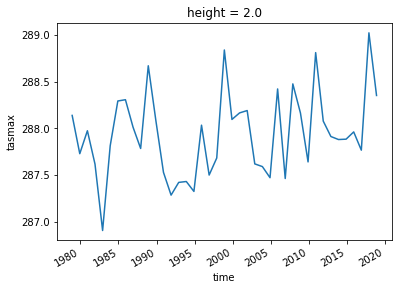

In [21]:
nat_mean.mean(['lat','lon']).plot()

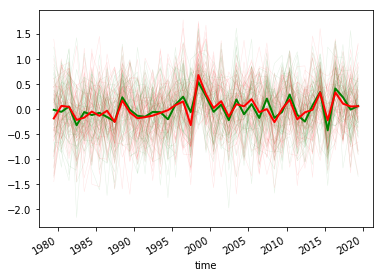

In [6]:
colors = {'ant':'red','nat':'green'}

nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_nat_winter_pr_gaussian_ensMean.nc')
all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_all_winter_pr_gaussian_ensMean.nc')

ant_mean = all_mean - nat_mean

for ens_mem in range(1,51):

    number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

    nat_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_nat_winter_pr_gaussian_ens'+number+'.nc')
    all_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_all_winter_pr_gaussian_ens'+number+'.nc')

    ant_mem = all_mem - nat_mem
    
    nat_mem.mean(['lat','lon']).plot(c=colors['nat'],linewidth=0.5,alpha=0.1)
    all_mem.mean(['lat','lon']).plot(c=colors['ant'],linewidth=0.5,alpha=0.1)
    #ant_mem.mean(['lat','lon']).plot(c=colors['ant'],linewidth=0.5,alpha=0.1)

nat_mean.mean(['lat','lon']).plot(c=colors['nat'],linewidth=2)
all_mean.mean(['lat','lon']).plot(c=colors['ant'],linewidth=2)
#ant_mean.mean(['lat','lon']).plot(c=colors['ant'],linewidth=2)

Text(15, 0.5, 'national precip')

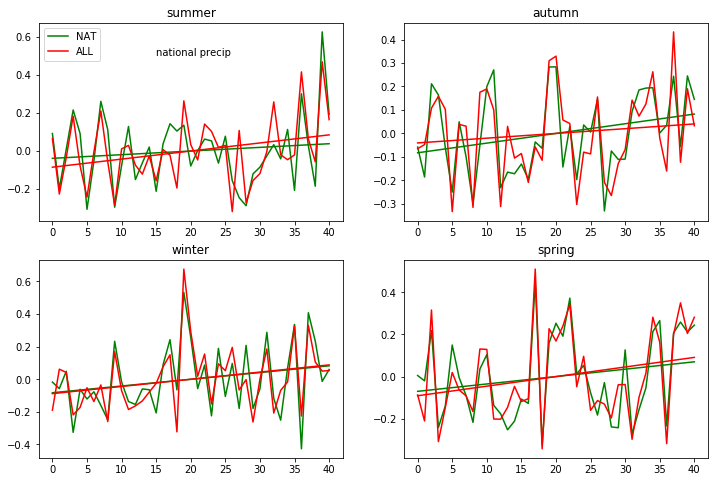

In [20]:
from scipy import stats

fig,axs = plt.subplots(2,2,figsize=(12,8))
axs = axs.flatten()

for i,s in enumerate(['summer','autumn','winter','spring']):
    
    nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_nat_'+s+'_pr_gaussian_ensMean.nc')
    all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_all_'+s+'_pr_gaussian_ensMean.nc')

    ts = nat_mean.mean(['lat','lon']).values
    result = stats.linregress([i for i in range(len(ts))], ts)
    lin_regression = [i*result.slope + result.intercept for i in range(len(ts))]
    axs[i].plot(ts,c='green',label='NAT')
    axs[i].plot(lin_regression,c='green')

    ts = all_mean.mean(['lat','lon']).values
    result = stats.linregress([i for i in range(len(ts))], ts)
    lin_regression = [i*result.slope + result.intercept for i in range(len(ts))]
    axs[i].plot(ts,c='red',label='ALL')
    axs[i].plot(lin_regression,c='red')
    
    axs[i].set_title(s)

axs[0].legend()

axs[0].text(15,0.5,'national precip')

Text(15, 0.5, 'national tasmax')

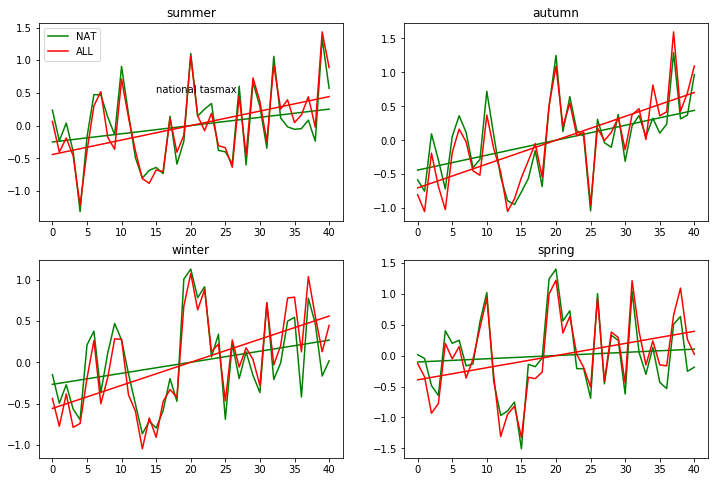

In [21]:
from scipy import stats

fig,axs = plt.subplots(2,2,figsize=(12,8))
axs = axs.flatten()

for i,s in enumerate(['summer','autumn','winter','spring']):
    
    nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_nat_'+s+'_tasmax_gaussian_ensMean.nc')
    all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tasmax/seasonal/ECHAM5_all_'+s+'_tasmax_gaussian_ensMean.nc')

    ts = nat_mean.mean(['lat','lon']).values
    result = stats.linregress([i for i in range(len(ts))], ts)
    lin_regression = [i*result.slope + result.intercept for i in range(len(ts))]
    axs[i].plot(ts,c='green',label='NAT')
    axs[i].plot(lin_regression,c='green')

    ts = all_mean.mean(['lat','lon']).values
    result = stats.linregress([i for i in range(len(ts))], ts)
    lin_regression = [i*result.slope + result.intercept for i in range(len(ts))]
    axs[i].plot(ts,c='red', label='ALL')
    axs[i].plot(lin_regression,c='red')
    
    axs[i].set_title(s)
    
axs[0].legend()

axs[0].text(15,0.5,'national tasmax')

Text(15, 0.5, 'national runoff')

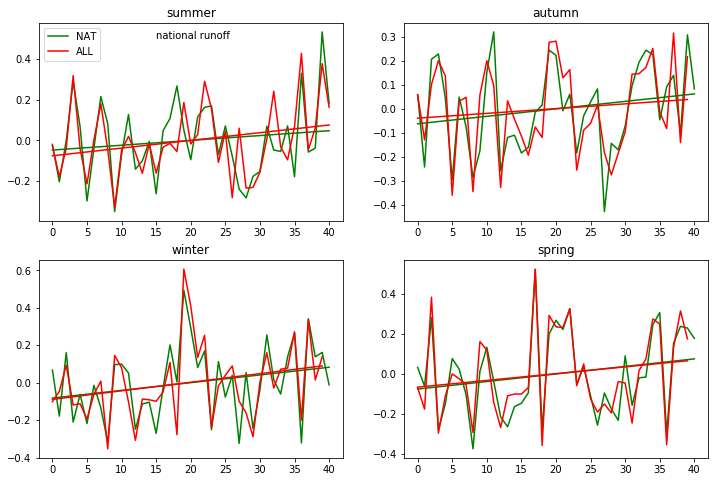

In [51]:
from scipy import stats

fig,axs = plt.subplots(2,2,figsize=(12,8))
axs = axs.flatten()

for i,s in enumerate(['summer','autumn','winter','spring']):
    
    nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/runoff/seasonal/ECHAM5_nat_'+s+'_mrro_gaussian_ensMean.nc')
    all_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/runoff/seasonal/ECHAM5_all_'+s+'_mrro_gaussian_ensMean.nc')
    
    ts = nat_mean.mean(['lat','lon']).values
    result = stats.linregress([i for i in range(len(ts))], ts)
    lin_regression = [i*result.slope + result.intercept for i in range(len(ts))]
    axs[i].plot(ts,c='green',label='NAT')
    axs[i].plot(lin_regression,c='green')

    ts = all_mean.mean(['lat','lon']).values
    result = stats.linregress([i for i in range(len(ts))], ts)
    lin_regression = [i*result.slope + result.intercept for i in range(len(ts))]
    axs[i].plot(ts,c='red', label='ALL')
    axs[i].plot(lin_regression,c='red')
    
    axs[i].set_title(s)
    
axs[0].legend()

axs[0].text(15,0.5,'national runoff')

In [46]:
nat_mean.mean(axis=1).values

array([-0.20085529, -0.01287319,  0.29169012,  0.05944058, -0.30414076,
        0.0323302 ,  0.19481738,  0.05323545, -0.41645857, -0.03609983,
        0.1776451 , -0.14536251, -0.15979583, -0.01691143, -0.29007619,
        0.00673584,  0.11920605,  0.31788103,  0.08390699, -0.0023136 ,
        0.16696325,  0.19850911,  0.18539335, -0.11683373,  0.06260903,
       -0.11327675, -0.26199345, -0.33361124, -0.18220288, -0.08018142,
        0.0315628 ,  0.01705312, -0.01485482,  0.04920294, -0.20707244,
        0.32884883, -0.08736131, -0.05440738,  0.53843969,  0.12121176])

In [45]:
nat_mean.shape

(40, 102)